# MWE 05 - Cartesian mesh pore network

This notebook demonstrates the synthetic mesh-like network example added to `voids.examples`.
Each mesh node is treated as a pore and nearest-neighbor mesh edges become throats.

It runs in the `default` Pixi environment and shows two cases:
- a 2D `20 x 20` mesh solved for single-phase flow along `x`
- a 3D `20 x 20 x 20` mesh using the same construction

This is a controlled Cartesian lattice for method development and solver validation. It is not a geologically realistic extracted rock network.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt

from voids.examples import make_cartesian_mesh_network
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path
from voids.physics.petrophysics import absolute_porosity, connectivity_metrics
from voids.physics.singlephase import FluidSinglePhase, PressureBC, solve
from voids.visualization import plot_network_plotly

examples_data = data_path()
examples_data.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.cmap"] = "viridis"

## 2D mesh example

Start with a `20 x 20` mesh. In the 2D case the network is treated as an extruded slab, so the `thickness` parameter controls the out-of-plane depth used in the sample geometry and pore volumes.


In [2]:
shape_2d = (20, 20)
net2d = make_cartesian_mesh_network(shape_2d, spacing=1.0, thickness=1.0)
metrics2d = connectivity_metrics(net2d)

summary2d = {
    "shape": shape_2d,
    "Np": net2d.Np,
    "Nt": net2d.Nt,
    "inlet_xmin_pores": int(net2d.pore_labels["inlet_xmin"].sum()),
    "outlet_xmax_pores": int(net2d.pore_labels["outlet_xmax"].sum()),
    "boundary_pores": int(net2d.pore_labels["boundary"].sum()),
    "bulk_volume": net2d.sample.resolved_bulk_volume(),
    "phi_abs": absolute_porosity(net2d),
    "mean_coordination": metrics2d.mean_coordination,
    "spans": metrics2d.spans,
}
summary2d

{'shape': (20, 20),
 'Np': 400,
 'Nt': 760,
 'inlet_xmin_pores': 20,
 'outlet_xmax_pores': 20,
 'boundary_pores': 76,
 'bulk_volume': 400.0,
 'phi_abs': 0.16147786239451534,
 'mean_coordination': 3.8,
 'spans': {'x': True, 'y': True}}

Q = 4.1336745441971055e-05
Kx = 4.1336745441971055e-05
mass balance error = 2.234724707365615e-19


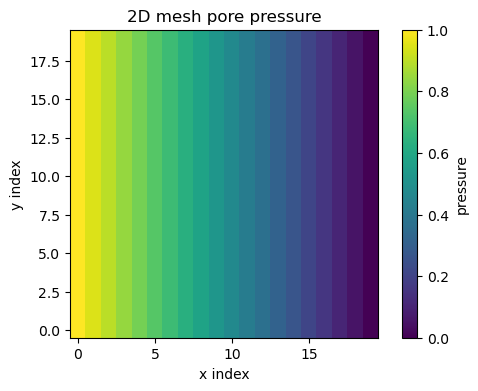

In [3]:
result2d = solve(
    net2d,
    fluid=FluidSinglePhase(viscosity=1.0),
    bc=PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0),
    axis="x",
)

print("Q =", result2d.total_flow_rate)
print("Kx =", result2d.permeability["x"])
print("mass balance error =", result2d.mass_balance_error)

pressure_2d = result2d.pore_pressure.reshape(shape_2d)
fig, ax = plt.subplots()
im = ax.imshow(pressure_2d.T, origin="lower", aspect="equal")
ax.set_title("2D mesh pore pressure")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
fig.colorbar(im, ax=ax, label="pressure")
plt.show()

## 2D network view with Plotly

The next cell renders the 2D mesh as an interactive 3D pore-throat network using Plotly. You can rotate, zoom, and pan the visualization.

In [4]:
try:
    fig2d = plot_network_plotly(
        net2d,
        point_scalars=result2d.pore_pressure,
        max_throats=None,
        title="2D network - interactive pressure field",
        layout_kwargs={"width": 800, "height": 600},
    )
    fig2d.show()
    print("2D interactive visualization complete")
except ImportError as exc:
    print(exc)

2D interactive visualization complete


## 3D mesh example

The same constructor also supports 3D shapes. Here we build and solve a `20 x 20 x 20` network.


In [5]:
shape_3d = (20, 20, 20)
net3d = make_cartesian_mesh_network(shape_3d, spacing=1.0)
metrics3d = connectivity_metrics(net3d)
result3d = solve(
    net3d,
    fluid=FluidSinglePhase(viscosity=1.0),
    bc=PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0),
    axis="x",
)

summary3d = {
    "shape": shape_3d,
    "Np": net3d.Np,
    "Nt": net3d.Nt,
    "inlet_xmin_pores": int(net3d.pore_labels["inlet_xmin"].sum()),
    "outlet_xmax_pores": int(net3d.pore_labels["outlet_xmax"].sum()),
    "phi_abs": absolute_porosity(net3d),
    "mean_coordination": metrics3d.mean_coordination,
    "Q": result3d.total_flow_rate,
    "Kx": result3d.permeability["x"],
    "mass_balance_error": result3d.mass_balance_error,
}
summary3d

{'shape': (20, 20, 20),
 'Np': 8000,
 'Nt': 22800,
 'inlet_xmin_pores': 400,
 'outlet_xmax_pores': 400,
 'phi_abs': 0.08723155601467658,
 'mean_coordination': 5.7,
 'Q': 0.0008267349088394548,
 'Kx': 4.133674544197274e-05,
 'mass_balance_error': 3.4607436359415394e-18}

## Save the 3D mesh to HDF5

You can serialize the generated 3D mesh network using the same HDF5 writer used elsewhere in the project.


In [6]:
out_h5 = examples_data / "cartesian_mesh_20x20x20_voids.h5"
save_hdf5(net3d, out_h5)
print("Saved HDF5:", out_h5)

Saved HDF5: /Users/dtvolpatto/Work/voids/examples/data/cartesian_mesh_20x20x20_voids.h5


## 3D Plotly visualization

The 3D mesh network colored by pore pressure. This interactive visualization uses Plotly for full 3D interactivity in the notebook.

In [7]:
try:
    fig3d = plot_network_plotly(
        net3d,
        point_scalars=result3d.pore_pressure,
        max_throats=1000,
        title="3D network (20x20x20) - interactive pressure field",
        layout_kwargs={"width": 800, "height": 600},
    )
    fig3d.show()
    print("3D interactive visualization complete")
except ImportError as exc:
    print(exc)

3D interactive visualization complete


## Notes

To change the mesh size, update `shape_2d` or `shape_3d` and rerun the corresponding cells.
Examples: `(40, 10)`, `(30, 30)`, `(12, 12, 24)`, `(20, 20, 20)`.

Other useful parameters in `make_cartesian_mesh_network(...)` are:
- `spacing` for center-to-center pore spacing
- `pore_radius` and `throat_radius` for the synthetic geometry
- `thickness` for 2D slab-like networks
